# Assignment 1: Classification
Multimodal dataset: https://www.kaggle.com/datasets/gianmarco96/upmcfood101  
https://visiir.isir.upmc.fr/

Download and unzip dataset (~7 minutes)

In [1]:
# !rm -rf dataset
# !mkdir dataset
# !curl -L -o ./dataset/upmcfood101.zip\
#     https://www.kaggle.com/api/v1/datasets/download/gianmarco96/upmcfood101
# !unzip dataset/upmcfood101.zip -d ./dataset
# !rm -rf dataset/upmcfood101.zip

In [2]:
!mkdir weight
!tree dataset/ -L 2

mkdir: cannot create directory ‘weight’: File exists
dataset/
├── images
│   ├── test
│   └── train
└── texts
    ├── test_titles.csv
    └── train_titles.csv

5 directories, 2 files


In [3]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import html
import re
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

## EDA

In [ ]:
column_names = ["image", "title", "category"]
train_df = pd.read_csv(
    "dataset/texts/train_titles.csv", header=None, names=column_names
)
test_df = pd.read_csv("dataset/texts/test_titles.csv", header=None, names=column_names)

print("Train dataframe:")
train_df.info()
print("\nTest dataframe:")
test_df.info()

train_df.head()

Train dataframe:
<class 'pandas.DataFrame'>
RangeIndex: 67972 entries, 0 to 67971
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   image     67972 non-null  str  
 1   title     67972 non-null  str  
 2   category  67972 non-null  str  
dtypes: str(3)
memory usage: 1.6 MB

Test dataframe:
<class 'pandas.DataFrame'>
RangeIndex: 22716 entries, 0 to 22715
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   image     22716 non-null  str  
 1   title     22716 non-null  str  
 2   category  22716 non-null  str  
dtypes: str(3)
memory usage: 532.5 KB


,image,title,category
0,apple_pie_851.jpg,Crock-Pot Ladies Crock-Pot Apple Pie Moonshine,apple_pie
1,apple_pie_140.jpg,Mom's Maple-Apple Pie Recipe | Taste of Home,apple_pie
2,apple_pie_858.jpg,Cookin&#8217; Canuck &#8211; Baked Apple Pie E...,apple_pie
3,apple_pie_449.jpg,Dutch Apple Pie Recipe | Just A Pinch Recipes,apple_pie
4,apple_pie_695.jpg,Our Share of the Harvest &raquo; Grandma&#8217...,apple_pie


In [5]:
categories = os.listdir("dataset/images/train")
print("Number of categories:", len(categories))
print(categories)

Number of categories: 101
['carrot_cake', 'club_sandwich', 'huevos_rancheros', 'ravioli', 'ramen', 'tuna_tartare', 'fried_rice', 'pho', 'chicken_curry', 'baklava', 'pulled_pork_sandwich', 'spaghetti_carbonara', 'deviled_eggs', 'apple_pie', 'mussels', 'steak', 'oysters', 'french_onion_soup', 'chicken_wings', 'cannoli', 'panna_cotta', 'pizza', 'frozen_yogurt', 'bruschetta', 'tiramisu', 'beef_carpaccio', 'garlic_bread', 'french_toast', 'escargots', 'poutine', 'strawberry_shortcake', 'shrimp_and_grits', 'caprese_salad', 'beet_salad', 'pork_chop', 'hot_dog', 'beignets', 'hamburger', 'edamame', 'donuts', 'chocolate_mousse', 'macarons', 'hot_and_sour_soup', 'prime_rib', 'ceviche', 'ice_cream', 'onion_rings', 'pad_thai', 'grilled_salmon', 'peking_duck', 'seaweed_salad', 'chicken_quesadilla', 'hummus', 'eggs_benedict', 'gnocchi', 'dumplings', 'filet_mignon', 'omelette', 'lasagna', 'cup_cakes', 'caesar_salad', 'red_velvet_cake', 'guacamole', 'bread_pudding', 'pancakes', 'breakfast_burrito', 'che

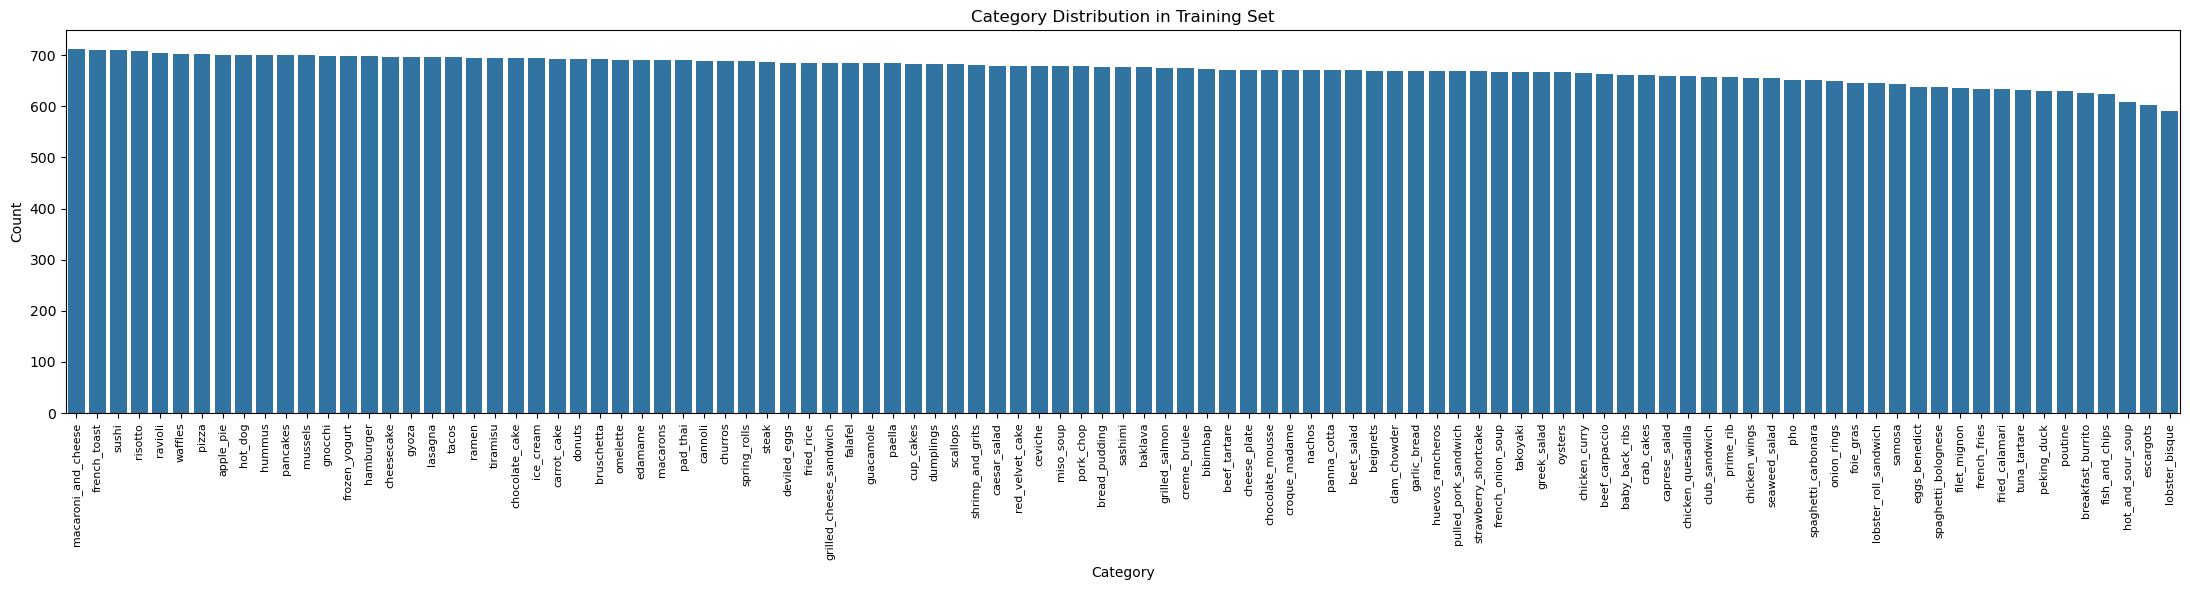

In [ ]:
# Visualizing Category Distribution mapping out class imbalance
plt.figure(figsize=(22, 6))
sns.countplot(
    data=train_df, x="category", order=train_df["category"].value_counts().index
)
plt.xticks(rotation=90, fontsize=8)
plt.title("Category Distribution in Training Set")
plt.xlabel("Category")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

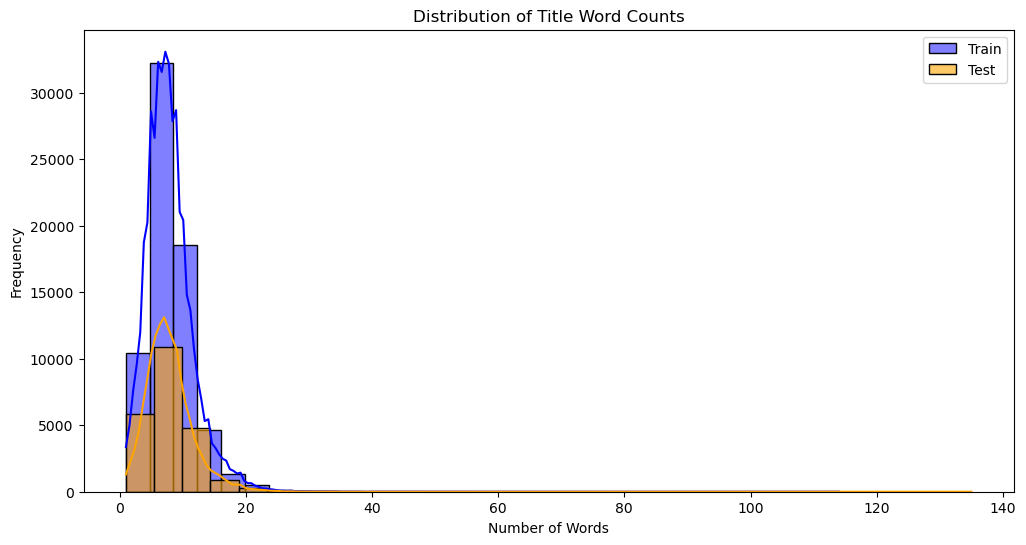

Average title length (train): 7.92 words
Max title length (train): 114 words


In [ ]:
# Analyzing text title length
train_df["title_length"] = train_df["title"].astype(str).apply(lambda x: len(x.split()))
test_df["title_length"] = test_df["title"].astype(str).apply(lambda x: len(x.split()))

plt.figure(figsize=(12, 6))
sns.histplot(
    data=train_df, x="title_length", bins=30, kde=True, color="blue", label="Train"
)
sns.histplot(
    data=test_df,
    x="title_length",
    bins=30,
    kde=True,
    color="orange",
    label="Test",
    alpha=0.6,
)
plt.title("Distribution of Title Word Counts")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.legend()
plt.show()

print(f"Average title length (train): {train_df['title_length'].mean():.2f} words")
print(f"Max title length (train): {train_df['title_length'].max()} words")

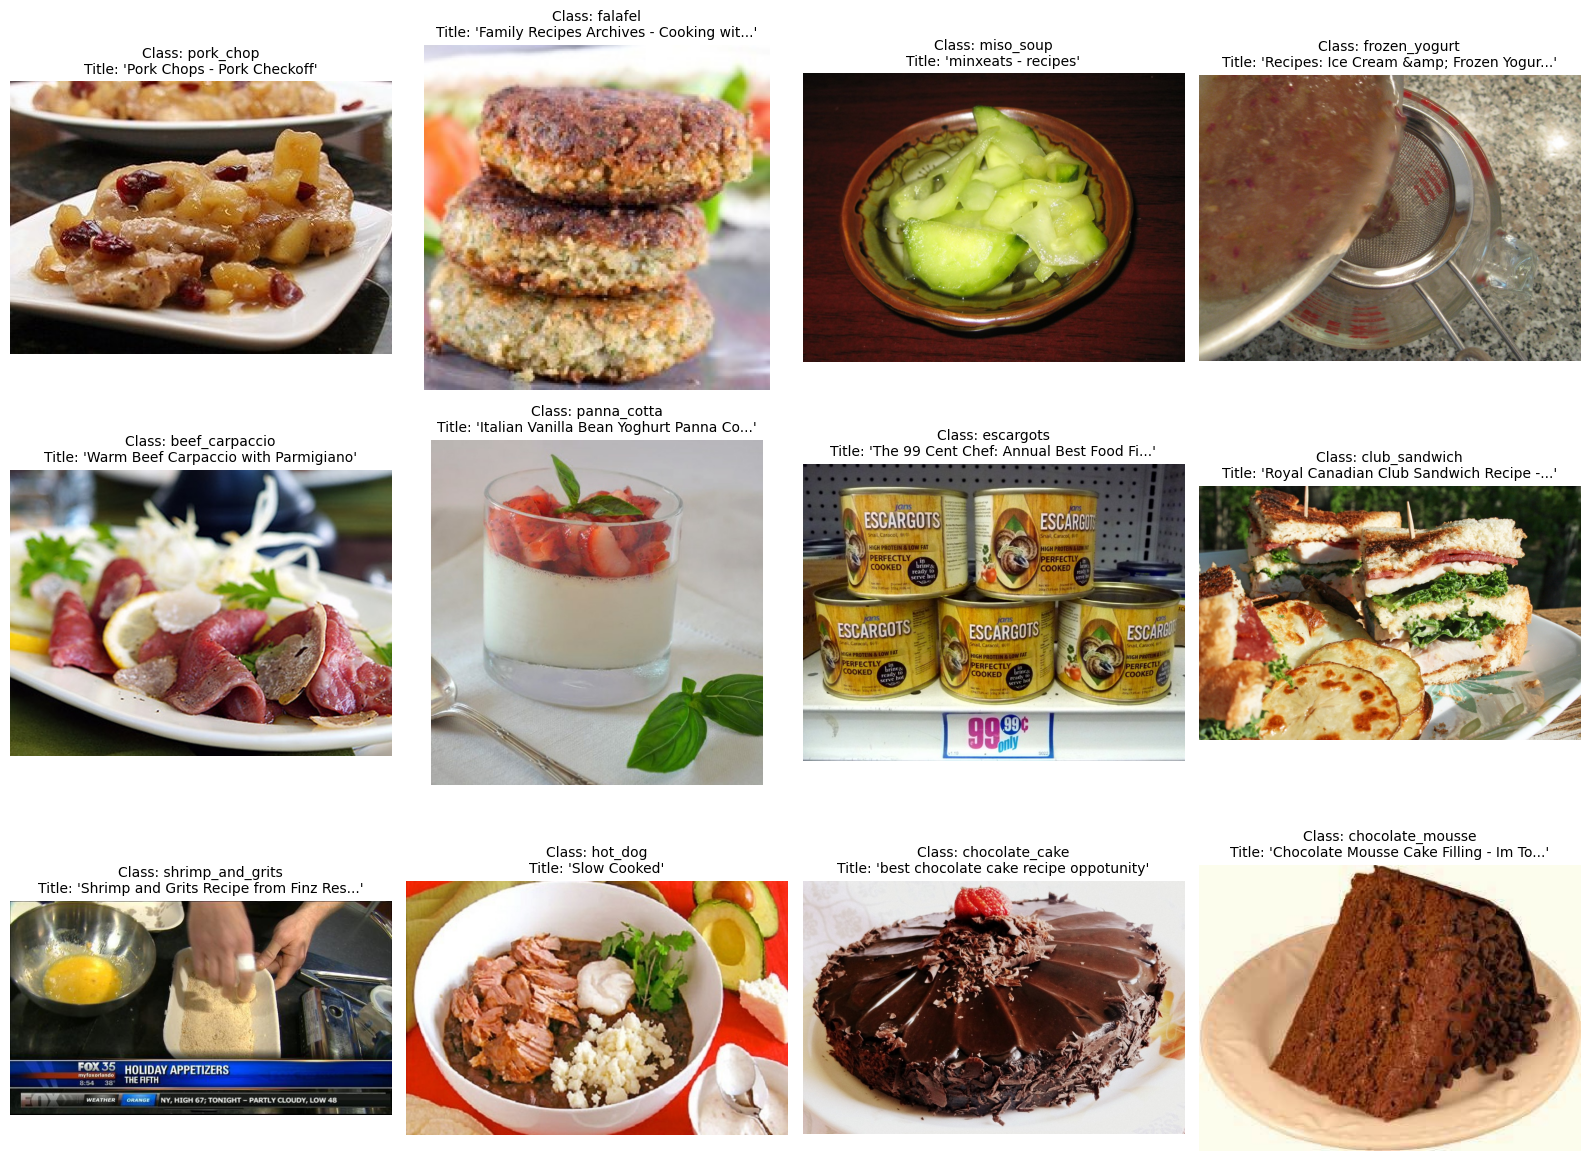

In [ ]:
# Visualize some sample images with their titles
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for ax in axes.flatten():
    # Sample a random row from the training dataset
    sample = train_df.sample(1).iloc[0]

    img_name = sample["image"]
    category = sample["category"]
    title_text = str(sample["title"])

    # Path format as described: dataset/images/{split}/{category}/{filename}
    img_path = os.path.join("dataset", "images", "train", category, img_name)

    try:
        img = Image.open(img_path)
        ax.imshow(img)

        # Truncate title sequence if it's too long for the subplot
        if len(title_text) > 40:
            title_text = title_text[:37] + "..."

        ax.set_title(f"Class: {category}\nTitle: '{title_text}'", fontsize=10)
    except Exception as e:
        ax.set_title(f"Missing/Error: {img_name}\n({category})", fontsize=10)

    ax.axis("off")

plt.tight_layout()
plt.show()

In [9]:
# Check for missing/null values in the datasets
print("Missing values in Train:")
print(train_df.isnull().sum())
print("\nMissing values in Test:")
print(test_df.isnull().sum())

Missing values in Train:
image           0
title           0
category        0
title_length    0
dtype: int64

Missing values in Test:
image           0
title           0
category        0
title_length    0
dtype: int64


In [10]:
train_df["title"][:10].to_list()

['Crock-Pot Ladies  Crock-Pot Apple Pie Moonshine',
 "Mom's Maple-Apple Pie Recipe | Taste of Home",
 'Cookin&#8217; Canuck &#8211; Baked Apple Pie Egg Rolls Recipe',
 'Dutch Apple Pie Recipe | Just A Pinch Recipes',
 'Our Share of the Harvest &raquo; Grandma&#8217;s Apple Pie with Oat Crumb Topping',
 'Apple Recipes | Only Best Recipes',
 'Crustless Apple Pie Recipe | Dessert Recipes | PBS Food',
 'Easy Apple Pie Recipe | How to Make Apple Pie | Thanksgiving Recipes',
 'How To Make Apple Pie (Mama&#8217;s Recipe) | Southern Plate',
 'Apple Pie Grilled Cheese Recipe: Cheddar']

In [ ]:
def clean_title(text):
    if not isinstance(text, str):
        return ""

    # Unescape HTML entities (e.g., &#8217; -> ')
    text = html.unescape(text)

    # Remove literal hex escapes like \xdb or \xe2
    text = re.sub(r"\\x[0-9a-fA-F]{2}", "", text)

    # Remove literal unicode escapes if they were loaded as raw strings
    text = text.encode("ascii", "ignore").decode("utf-8")

    # Clean up multiple spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


# Apply the cleaning function
train_df["title"] = train_df["title"].apply(clean_title)
test_df["title"] = test_df["title"].apply(clean_title)

In [12]:
train_df["title"][:10].to_list()

['Crock-Pot Ladies Crock-Pot Apple Pie Moonshine',
 "Mom's Maple-Apple Pie Recipe | Taste of Home",
 'Cookin Canuck Baked Apple Pie Egg Rolls Recipe',
 'Dutch Apple Pie Recipe | Just A Pinch Recipes',
 'Our Share of the Harvest Grandmas Apple Pie with Oat Crumb Topping',
 'Apple Recipes | Only Best Recipes',
 'Crustless Apple Pie Recipe | Dessert Recipes | PBS Food',
 'Easy Apple Pie Recipe | How to Make Apple Pie | Thanksgiving Recipes',
 'How To Make Apple Pie (Mamas Recipe) | Southern Plate',
 'Apple Pie Grilled Cheese Recipe: Cheddar']

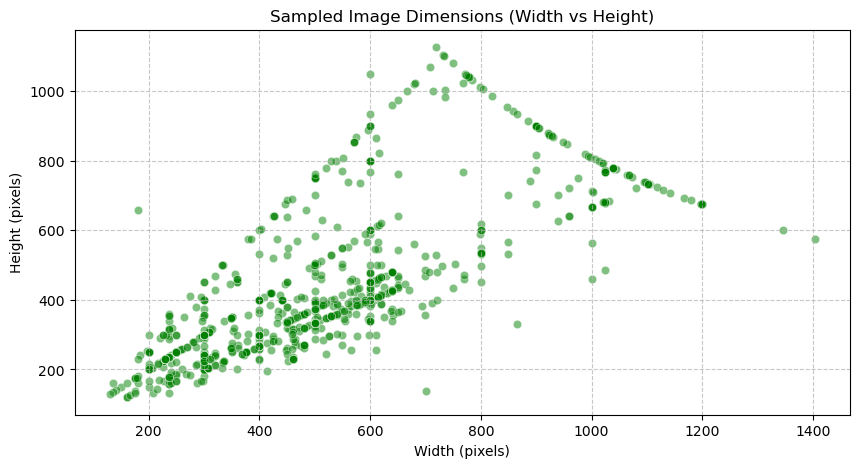

Average Width: 545px
Average Height: 447px


In [ ]:
# Check image sizes/resolutions (sampling 1000 images for speed)
sample_images = train_df.sample(min(1000, len(train_df)))
widths = []
heights = []

for _, row in sample_images.iterrows():
    img_path = os.path.join("dataset", "images", "train", row["category"], row["image"])
    try:
        with Image.open(img_path) as img:
            widths.append(img.width)
            heights.append(img.height)
    except Exception as e:
        pass

plt.figure(figsize=(10, 5))
sns.scatterplot(x=widths, y=heights, alpha=0.5, color="green")
plt.title("Sampled Image Dimensions (Width vs Height)")
plt.xlabel("Width (pixels)")
plt.ylabel("Height (pixels)")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

print(f"Average Width: {np.mean(widths):.0f}px")
print(f"Average Height: {np.mean(heights):.0f}px")

## Prepare the dataset

In [ ]:
# Create a mapping from category to numerical index
categories = sorted(train_df["category"].unique())
category_to_idx = {cat: i for i, cat in enumerate(categories)}
idx_to_category = {i: cat for i, cat in enumerate(categories)}


class UpmcFood101Dataset(Dataset):
    def __init__(self, df, split="train", transform=None, root_dir="dataset/images"):
        """
        Args:
            df (pandas.DataFrame): DataFrame containing image, title, and category.
            split (str): 'train' or 'test'. Used to build the directory path.
            transform (callable, optional): Optional transform to be applied on an image.
            root_dir (str): Root directory of the images.
        """
        self.df = df
        self.split = split
        self.transform = transform
        self.root_dir = root_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_name = row["image"]
        title = str(row["title"])
        category = row["category"]
        label = category_to_idx[category]

        img_path = os.path.join(self.root_dir, self.split, category, img_name)

        try:
            image = Image.open(img_path).convert("RGB")
        except Exception as e:
            # Fallback for missing/corrupted images
            image = Image.new("RGB", (224, 224))

        if self.transform:
            image = self.transform(image)

        # Return all needed elements: image for both approaches, text for few-shot, label for evaluation/training
        return {
            "image": image,
            "text": title,
            "label": torch.tensor(label, dtype=torch.long),
            "category": category,
        }


# Define basic image transformations (Standard CLIP normalization)
# Alternatively, you can use transformers.CLIPProcessor directly in the training loop
clip_transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            (0.48145466, 0.4578275, 0.40821073), (0.26862954, 0.26130258, 0.27577711)
        ),
    ]
)

# Create Dataset instances
train_dataset = UpmcFood101Dataset(train_df, split="train", transform=clip_transform)
test_dataset = UpmcFood101Dataset(test_df, split="test", transform=clip_transform)

# Create DataLoader instances
train_loader = DataLoader(
    train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True
)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

# Verify a batch
sample_batch = next(iter(train_loader))
print("\nBatch shapes:")
print(f"Images: {sample_batch['image'].shape}")
print(f"Texts: {len(sample_batch['text'])} items")
print(f"Labels: {sample_batch['label'].shape}")

Train dataset size: 67972
Test dataset size: 22716

Batch shapes:
Images: torch.Size([32, 3, 224, 224])
Texts: 32 items
Labels: torch.Size([32])


## Model and training

In this dataset, each sample contains:
* An image (picture of food)
* A text (title)
* A class (category)

There are 101 categories. For each sample, we will predict the class of the sample. It's a classification problem, with 101 classes.

We use 2 approaches with CLIP pretrain model:
1. **Zero shot:** We encode the 101 classes into text, as "A photo of {class}", then encode it with the text encoder. For each sample, the model will pass the image through the image encoder to get image feature, then use Cosine similarity with the 101 text features to find the matching class. This approach will not use the text (title) of the sample, we only use the image and class. There will be no training because it is zero shot.
2. **Few shot:** For each sample, we pass the image into the image encoder, and text into the text encoder, to get image feature and text feature. Then we aggregate them (concatenation), and pass through an MLP and softmax classifier. This approach will use the text, image, and class of a sample. We will train this model.

In [ ]:
import torch
import torch.nn as nn
from transformers import CLIPModel, CLIPProcessor
from tqdm import tqdm
from sklearn.metrics import accuracy_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load CLIP model and processor
model_name = "openai/clip-vit-base-patch32"
processor = CLIPProcessor.from_pretrained(model_name)
clip_model = CLIPModel.from_pretrained(model_name).to(device)

# Freeze CLIP parameters
for param in clip_model.parameters():
    param.requires_grad = False

/home/minht/miniconda3/envs/dl/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 398/398 [00:00<00:00, 60032.83it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# Approach 1: Zero-shot Classification

category_texts = [f"A photo of {category.replace('_', ' ')}" for category in categories]

# Pre-compute text features for all 101 categories
text_inputs = processor(
    text=category_texts, return_tensors="pt", padding=True, truncation=True
).to(device)
with torch.no_grad():
    text_features = clip_model.get_text_features(**text_inputs)["pooler_output"]
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)


def evaluate_zero_shot(dataloader):
    clip_model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Zero-shot evaluation"):
            images = batch["image"].to(device)
            labels = batch["label"].to(device)

            # Note: Assuming 'images' passed from our dataset is compatible with processor/directly to model
            # Since previously applied clip_transform, the shape is already [N,C,H,W]. Wait!
            # It's better to get raw image features.
            image_features = clip_model.get_image_features(pixel_values=images)[
                "pooler_output"
            ]
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)

            # Cosine similarity (temperature scaled if needed, but not necessary for argmax)
            similarity = image_features @ text_features.T

            preds = similarity.argmax(dim=-1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return accuracy_score(all_labels, all_preds)


zero_shot_acc = evaluate_zero_shot(test_loader)
print(f"Zero-shot accuracy on test set: {zero_shot_acc:.4f}")

Zero-shot evaluation: 100%|██████████| 710/710 [00:43<00:00, 16.34it/s]

Zero-shot accuracy on test set: 0.6283


In [ ]:
# Approach 2: Multimodal MLP Classifier (using both Image + Text title)


class MultimodalClassifier(nn.Module):
    def __init__(self, clip_model, num_classes=101, hidden_dim=512):
        super().__init__()
        self.clip = clip_model

        # Frozen CLIP model
        for param in self.clip.parameters():
            param.requires_grad = False

        # CLIP outputs 512-dim features for both image and text
        input_dim = 512 + 512

        self.classifier = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, pixel_values, text_inputs):
        with torch.no_grad():
            img_feat = self.clip.get_image_features(pixel_values=pixel_values)[
                "pooler_output"
            ]
            txt_feat = self.clip.get_text_features(**text_inputs)["pooler_output"]

            # L2 Normalize
            img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)
            txt_feat = txt_feat / txt_feat.norm(dim=-1, keepdim=True)

        combined = torch.cat((img_feat, txt_feat), dim=-1)
        logits = self.classifier(combined)
        return logits


model = MultimodalClassifier(clip_model).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=1e-3)


def train_multimodal(
    model,
    train_loader,
    test_loader,
    epochs=5,
    patience=3,
    save_path="weight/multimodal.pth",
):
    best_acc = 0.0
    patience_counter = 0

    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        correct = 0
        total = 0

        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
            images = batch["image"].to(device)
            texts = batch["text"]
            labels = batch["label"].to(device)

            text_inputs = processor(
                text=texts, return_tensors="pt", padding=True, truncation=True
            ).to(device)

            optimizer.zero_grad()
            outputs = model(images, text_inputs)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        epoch_train_loss = train_loss / len(train_loader)
        epoch_train_acc = correct / total
        history["train_loss"].append(epoch_train_loss)
        history["train_acc"].append(epoch_train_acc)
        print(
            f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {100.*epoch_train_acc:.2f}%"
        )

        # evaluate
        model.eval()
        test_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for batch in tqdm(test_loader, desc=f"Epoch {epoch+1}/{epochs} [Test]"):
                images = batch["image"].to(device)
                texts = batch["text"]
                labels = batch["label"].to(device)

                text_inputs = processor(
                    text=texts, return_tensors="pt", padding=True, truncation=True
                ).to(device)

                outputs = model(images, text_inputs)
                loss = criterion(outputs, labels)

                test_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        epoch_test_loss = test_loss / len(test_loader)
        epoch_test_acc = correct / total
        history["test_loss"].append(epoch_test_loss)
        history["test_acc"].append(epoch_test_acc)
        print(
            f"Test Loss: {epoch_test_loss:.4f} | Test Acc: {100.*epoch_test_acc:.2f}%"
        )

        if epoch_test_acc > best_acc:
            best_acc = epoch_test_acc
            patience_counter = 0
            torch.save(model.state_dict(), save_path)
            print(f"Saved new best model with val acc: {100.*best_acc:.2f}%")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}")
                break

    # Load best model
    model.load_state_dict(torch.load(save_path))
    return best_acc, history


epochs = 1
test_accuracy, history = train_multimodal(
    model, train_loader, test_loader, epochs=epochs, patience=3
)
print(f"Few-shot optimal test accuracy: {test_accuracy*100:.2f}%")

Epoch 1/1 [Train]:   0%|          | 0/2125 [00:00<?, ?it/s]

Epoch 1/1 [Train]: 100%|██████████| 2125/2125 [02:19<00:00, 15.26it/s]


Train Loss: 0.8731 | Train Acc: 82.37%


Epoch 1/1 [Test]: 100%|██████████| 710/710 [00:47<00:00, 15.09it/s]


Test Loss: 0.3650 | Test Acc: 91.09%
Saved new best model with val acc: 91.09%
Few-shot optimal test accuracy: 91.09%


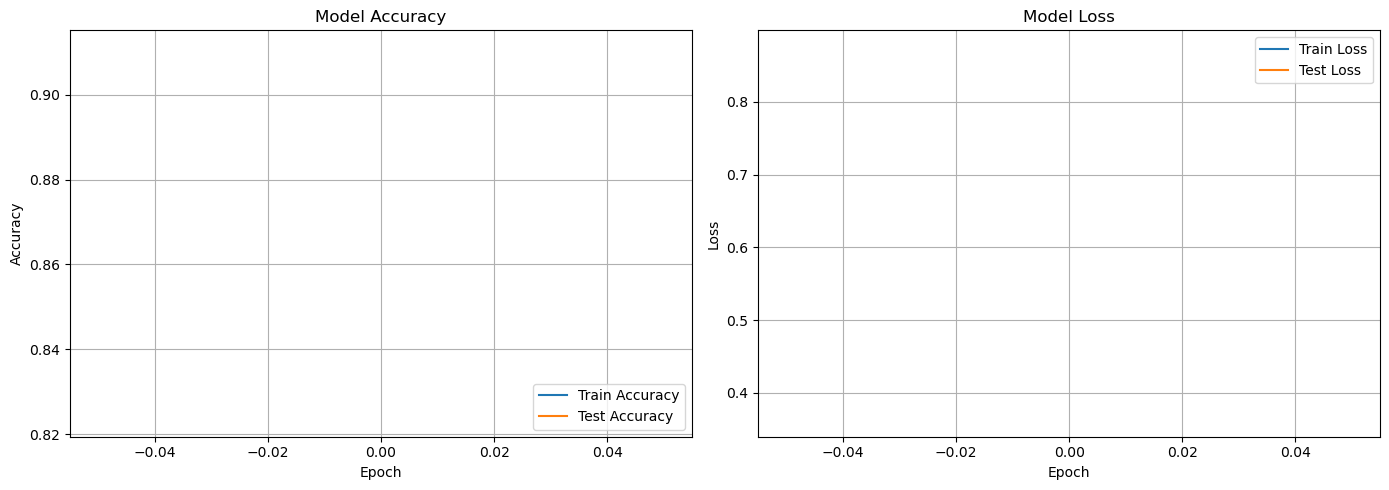

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["test_acc"], label="Test Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(loc="lower right")
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["test_loss"], label="Test Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(loc="upper right")
plt.grid(True)

plt.tight_layout()
plt.show()

In [21]:
comparison_df = pd.DataFrame(
    {
        "Approach": ["Zero-Shot CLIP", "Few-Shot Multimodal MLP"],
        "Data Used": ["Image + Class Text", "Image + Text Title + Label"],
        "Training Required": ["No", "Yes"],
        "Test Accuracy": [f"{zero_shot_acc*100:.2f}%", f"{test_accuracy*100:.2f}%"],
    }
)
comparison_df

,Approach,Data Used,Training Required,Test Accuracy
0,Zero-Shot CLIP,Image + Class Text,No,62.83%
1,Few-Shot Multimodal MLP,Image + Text Title + Label,Yes,91.09%


# Conclusion

We have evaluated two approaches using the CLIP base model:
1. **Zero-shot**: Directly compared image embeddings to the texts "A photo of {class}" via Cosine Similarity, yielding base capabilities.
2. **Few-shot Multimodal MLP**: Jointly passed Image embeddings & Text embeddings from the titles into an MLP and trained it. This approach leverages text features unique for each sample and fits to the specific UPMC dataset.